# Convert h5 files into npz files, referencing the stored format in the example files

In [14]:
import numpy as np
import h5py
from skimage.transform import resize

import matplotlib.pyplot as plt

import os
from tqdm import tqdm

In [4]:

def h5_to_npz(rec_h5_path=None, tru_h5_path=None, out_npz_path=None):
    """
    re
    Convert a pair of h5 files (reco, true) to a single .npz file with "reco" and "true" arrays.
    Each file has one or more keys for events (e.g. '0/frame_loose_lf0'), each becoming an entry (n dimension).
    Each image is resized to (1, 512, 512).
    """
    def load_resize_stack(h5file, prefix):
        frames = []
        print(h5file.keys())
        # Search recursively over all datasets in the file, flatten keys
        def get_all_dataset_keys(group, prefix=""):
            keys = []
            for k in group.keys():
                item = group[k]
                if isinstance(item, h5py.Group):
                    keys.extend(get_all_dataset_keys(item, prefix+k+"/"))
                else:
                    keys.append(prefix+k)
            return keys

        all_keys = get_all_dataset_keys(h5file)
        for k in sorted(all_keys, key=lambda x: int(x.split('/')[0])):  # assumes key is like '0/frame_loose_lf0'
            if k.endswith(prefix):
                arr = np.array(h5file[k])
                arr = arr[1984*2:, :]
                arr_resized = resize(arr, (512, 512), order=1, mode='reflect', anti_aliasing=True, preserve_range=True).astype(arr.dtype)
                frames.append(arr_resized[None, ...])  # shape (1, 512, 512)
        if len(frames) == 0:
            raise ValueError(f"No keys ending with {prefix} found in {h5file.filename}")
        stacked = np.stack(frames, axis=0)  # shape (n,1,512,512)
        return stacked  # do NOT add extra None dimension

    # with h5py.File(rec_h5_path, 'r') as f_reco, h5py.File(tru_h5_path, 'r') as f_true:
    with h5py.File(rec_h5_path, 'r') as f_reco:
        reco_stack = load_resize_stack(f_reco, "raw")
        # true_stack = load_resize_stack(f_true, "frame_deposplat0")
        # TODO: use reco files for truth for now
        true_stack = load_resize_stack(f_reco, "raw")
        np.savez_compressed(
            out_npz_path,
            reco=reco_stack.astype(np.float32),
            truth=true_stack.astype(np.float32)
        )
        print(f"Saved {out_npz_path}: reco {reco_stack.shape}, truth {true_stack.shape}")


In [48]:
# # Example usage for a single pair:
# rec_h5 = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/g4-rec-0.h5"
# tru_h5 = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/g4-tru-0.h5"
# out_npz = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/example_output.npz"
# h5_to_npz(rec_h5, tru_h5, out_npz)

# file_base_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb"
# file_base_dir = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5"
file_base_dir = "/scratch/7DayLifetime/munjung/ICARUS/plane0"
subdirs = os.listdir(file_base_dir)
# for subdir in tqdm(subdirs):
for subdir in tqdm(["83487027_0"]):
    # rec_h5_path = os.path.join(file_base_dir, subdir, "g4-rec-0.h5")
    # tru_h5_path = os.path.join(file_base_dir, subdir, "g4-tru-0.h5")
    rec_h5_path = os.path.join(file_base_dir, subdir, "g4-raw-0_0.h5")
    tru_h5_path = os.path.join(file_base_dir, subdir, "g4-raw-0_0.h5")
    out_npz_path = os.path.join(file_base_dir, subdir, subdir + "_tpc0_plane2.npz")
    try:
        h5_to_npz(rec_h5_path, tru_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} and {tru_h5_path}: {e}")


100%|██████████| 1/1 [00:00<00:00, 1182.16it/s]

Error processing /scratch/7DayLifetime/munjung/ICARUS/plane0/83487027_0/g4-raw-0_0.h5 and /scratch/7DayLifetime/munjung/ICARUS/plane0/83487027_0/g4-raw-0_0.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = '/scratch/7DayLifetime/munjung/ICARUS/plane0/83487027_0/g4-raw-0_0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


# SBND

In [ ]:
file_base_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/intrnue"
subdirs = os.listdir(file_base_dir)
for subdir in tqdm(subdirs):
    rec_h5_path = os.path.join(file_base_dir, subdir, "g4-rec-0.h5")
    tru_h5_path = os.path.join(file_base_dir, subdir, "g4-tru-0.h5")
    out_npz_path = os.path.join(file_base_dir, subdir, subdir + "_tpc0_plane2.npz")
    try:
        h5_to_npz(rec_h5_path, tru_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} and {tru_h5_path}: {e}")


In [6]:
# def h5_to_npz(rec_h5_path=None, tru_h5_path=None, out_npz_path=None):
#     """
#     Convert a pair of h5 files (reco, true) to a single .npz file with "reco" and "true" arrays.
#     Each file has one or more keys for events (e.g. '0/frame_loose_lf0'), each becoming an entry (n dimension).
#     Each image is resized to (1, 512, 512).
#     """
#     def load_resize_stack(h5file, prefix):
#         frames = []
#         print(h5file.keys())
#         # Search recursively over all datasets in the file, flatten keys
#         def get_all_dataset_keys(group, prefix=""):
#             keys = []
#             for k in group.keys():
#                 item = group[k]
#                 if isinstance(item, h5py.Group):
#                     keys.extend(get_all_dataset_keys(item, prefix+k+"/"))
#                 else:
#                     keys.append(prefix+k)
#             return keys

#         all_keys = get_all_dataset_keys(h5file)
#         for k in sorted(all_keys, key=lambda x: int(x.split('/')[0])):  # assumes key is like '0/frame_loose_lf0'
#             if k.endswith(prefix):
#                 arr = np.array(h5file[k])
#                 arr = arr[1984*2:, :]
#                 arr_resized = resize(arr, (512, 512), order=1, mode='reflect', anti_aliasing=True, preserve_range=True).astype(arr.dtype)
#                 frames.append(arr_resized[None, ...])  # shape (1, 512, 512)
#         if len(frames) == 0:
#             raise ValueError(f"No keys ending with {prefix} found in {h5file.filename}")
#         stacked = np.stack(frames, axis=0)  # shape (n,1,512,512)
#         return stacked  # do NOT add extra None dimension

#     # with h5py.File(rec_h5_path, 'r') as f_reco, h5py.File(tru_h5_path, 'r') as f_true:
#     with h5py.File(rec_h5_path, 'r') as f_reco:
#         reco_stack = load_resize_stack(f_reco, "frame_loose_lf1")
#         # true_stack = load_resize_stack(f_true, "frame_deposplat0")
#         # TODO: use reco files for truth for now
#         true_stack = load_resize_stack(f_reco, "frame_loose_lf1")
#         np.savez_compressed(
#             out_npz_path,
#             reco=reco_stack.astype(np.float32),
#             truth=true_stack.astype(np.float32)
#         )
#         print(f"Saved {out_npz_path}: reco {reco_stack.shape}, truth {true_stack.shape}")


In [ ]:
file_base_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/intrnue"
subdirs = os.listdir(file_base_dir)
for subdir in tqdm(subdirs):
    rec_h5_path = os.path.join(file_base_dir, subdir, "g4-rec-1.h5")
    tru_h5_path = os.path.join(file_base_dir, subdir, "g4-tru-1.h5")
    out_npz_path = os.path.join(file_base_dir, subdir, subdir + "_tpc1_plane2.npz")
    try:
        h5_to_npz(rec_h5_path, tru_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} and {tru_h5_path}: {e}")


In [ ]:
file_base_dir = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb"
subdirs = os.listdir(file_base_dir)
for subdir in tqdm(subdirs):
    rec_h5_path = os.path.join(file_base_dir, subdir, "g4-rec-1.h5")
    tru_h5_path = os.path.join(file_base_dir, subdir, "g4-tru-1.h5")
    out_npz_path = os.path.join(file_base_dir, subdir, subdir + "_tpc1_plane2.npz")
    try:
        h5_to_npz(rec_h5_path, tru_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} and {tru_h5_path}: {e}")


# ICARUS

In [10]:
def h5_to_npz(rec_h5_path=None, out_npz_path=None):
    """
    Convert a pair of h5 files (reco, true) to a single .npz file with "reco" and "true" arrays.
    Each file has one or more keys for events (e.g. '0/frame_loose_lf0'), each becoming an entry (n dimension).
    Each image is resized to (1, 512, 512).
    """
    import re

    def load_resize_stack(h5file, prefix):
        frames = []
        # print(h5file.keys())
        # Search recursively over all datasets in the file, flatten keys
        def get_all_dataset_keys(group, prefix=""):
            keys = []
            for k in group.keys():
                item = group[k]
                if isinstance(item, h5py.Group):
                    keys.extend(get_all_dataset_keys(item, prefix+k+"/"))
                else:
                    keys.append(prefix+k)
            return keys

        def extract_event_number(x):
            # Try extracting integer from first path component, supports various formats
            first = x.split('/')[0]
            # Handles "event_0", "0", etc.
            digits = re.findall(r'\d+', first)
            return int(digits[0]) if digits else -1  # put non-numeric at the beginning

        all_keys = get_all_dataset_keys(h5file)
        nrows, ncols = (512, 512)
        cscale = 1.
        for k in sorted(all_keys, key=extract_event_number):
            if k.endswith(prefix):
                arr = np.array(h5file[k])
                planearr = arr/cscale
                h, w = planearr.shape
                ll = planearr[:(h//nrows)*nrows, :(w//nrows)*nrows].reshape(h//nrows, nrows, -1, ncols).swapaxes(1,2).reshape(-1, nrows, ncols)
                # print(ll.shape)
                for l in ll:
                    frames.append(l)

        if len(frames) == 0:
            raise ValueError(f"No keys ending with {prefix} found in {h5file.filename}")

        # Stack frames along axis 0 and 1
        stacked = np.stack(frames, axis=0)
   
        # add extra dimension at axis 1
        stacked = np.expand_dims(stacked, axis=1)
        return stacked  # do NOT add extra None dimension

    # with h5py.File(rec_h5_path, 'r') as f_reco, h5py.File(tru_h5_path, 'r') as f_true:
    with h5py.File(rec_h5_path, 'r') as f_reco:
        reco_stack = load_resize_stack(f_reco, "deconvolved_signal")
        # true_stack = load_resize_stack(f_true, "frame_deposplat0")
        # TODO: use reco files for truth for now
        np.savez_compressed(
            out_npz_path,
            reco=reco_stack.astype(np.float32),
        )
        # print(f"Saved {out_npz_path}: reco {reco_stack.shape}")


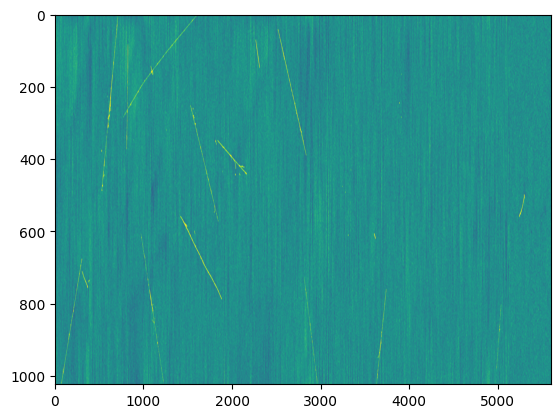

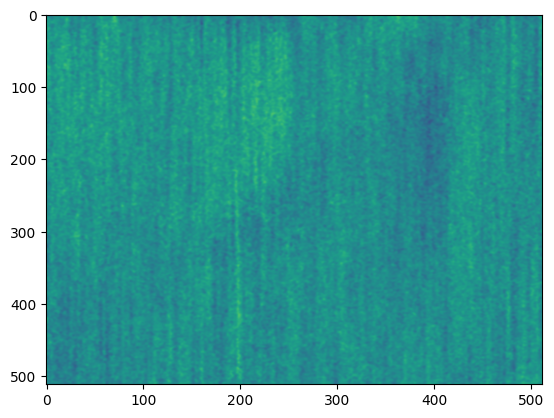

In [19]:
# ICARUS
file_base_dir = "/scratch/7DayLifetime/munjung/ICARUS/plane1"
outdir = "/scratch/7DayLifetime/munjung/ICARUS/plane1_npz"
files = os.listdir(file_base_dir)
filename = files[0]
f_reco = h5py.File(os.path.join(file_base_dir, filename), 'r')
arr = f_reco['event_0']['deconvolved_signal']
arr.shape

plt.imshow(arr, aspect='auto', vmin=-1, vmax=1)
# plt.title(f"event {fidx}")
plt.show()

plt.imshow(arr[:512, :512], aspect='auto', vmin=-1, vmax=1)
# plt.title(f"event {fidx}")
plt.show()


In [ ]:
# ICARUS
file_base_dir = "/scratch/7DayLifetime/munjung/ICARUS/plane0"
outdir = "/scratch/7DayLifetime/munjung/ICARUS/plane0_npz"
files = os.listdir(file_base_dir)
for fidx in tqdm(range(len(files))):
    filename = files[fidx]
    rec_h5_path = os.path.join(file_base_dir, filename)
    out_npz_path = os.path.join(outdir, filename.replace(".h5", ".npz"))
    try:
        h5_to_npz(rec_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} : {e}")

  0%|          | 0/7996 [00:00<?, ?it/s]

  0%|          | 18/7996 [02:22<17:41:57,  7.99s/it]

In [ ]:
# ICARUS
file_base_dir = "/scratch/7DayLifetime/munjung/ICARUS/plane1"
outdir = "/scratch/7DayLifetime/munjung/ICARUS/plane1_npz"
files = os.listdir(file_base_dir)
for fidx in tqdm(range(len(files))):
    filename = files[fidx]
    rec_h5_path = os.path.join(file_base_dir, filename)
    out_npz_path = os.path.join(outdir, filename.replace(".h5", ".npz"))
    try:
        h5_to_npz(rec_h5_path, out_npz_path)
    except Exception as e:
        print(f"Error processing {rec_h5_path} : {e}")

  0%|          | 0/7997 [00:00<?, ?it/s]

In [ ]:
# Downscale and crop frame_loose_lf0_array to (512, 512) in each image

# Downsample to (512, 512), dropping extra pixels if needed
# Downsample to (512, 512) using skimage.transform.resize for (anti-aliased) downsampling



In [20]:
import matplotlib.pyplot as plt

example_npz_file = "/scratch/7DayLifetime/munjung/ICARUS/plane1_npz/82090893_636-bnb-nom-tpc3-plane1.npz"
data_npz = np.load(example_npz_file)
print(data_npz.keys())
print(data_npz["reco"].astype(np.float32).shape)

# example_h5_file = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/g4-rec-0.h5"
# data_h5_reco = h5py.File(example_h5_file, 'r')
# print(list(data_h5_reco.keys()))
# data_arr_reco = np.array(data_h5_reco['100/frame_loose_lf0'])
# print(data_arr_reco.shape)
# data_arr_reco_resized = resize(data_arr_reco[1984*2:, :], 
#                                 (512, 512), order=1, mode='reflect', anti_aliasing=True, preserve_range=True).astype(data_arr_reco.dtype)
# print(data_arr_reco_resized.shape)

# example_h5_file = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/g4-tru-0.h5"
# data_h5_truth = h5py.File(example_h5_file, 'r')
# data_arr_truth = np.array(data_h5_truth['0/frame_deposplat0'])
# print(data_arr_truth.shape)


# new_npz_file = "/scratch/7DayLifetime/munjung/DNN_ROI/SBND/test/bnb/25801404_10/example_output.npz"
# data_npz_new = np.load(new_npz_file)
# print(data_npz_new["reco"].astype(np.float32).shape)

KeysView(NpzFile '/scratch/7DayLifetime/munjung/ICARUS/plane1_npz/82090893_636-bnb-nom-tpc3-plane1.npz' with keys: reco)
(100, 1, 512, 512)


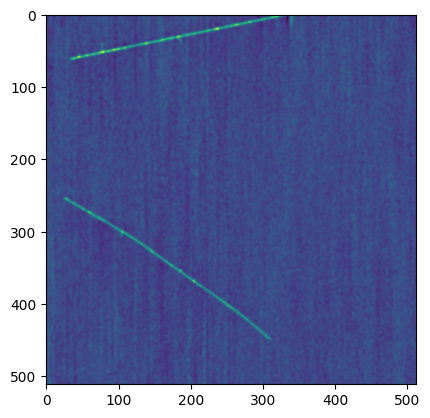

In [21]:
plt.imshow(data_npz["reco"][0][0])
plt.show();

# plt.imshow(data_arr_reco_resized)
# plt.show()

# plt.imshow(data_npz_new["reco"][0][0])
# plt.show()

In [ ]:
data_npz